<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Bernoulli_Equation_Venturi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bernoulli's Principle in a Venturi Tube: Flow Visualization

## Project Overview
This notebook contains a Python-based numerical simulation and animation of fluid flow through a Venturi tube. The visualization is designed to demonstrate the relationship between fluid velocity and pressure as described by Bernoulli's equation. By utilizing a staggered-grid-inspired particle system, the animation highlights how fluid accelerates in constricted sections and how the static pressure responds to these changes in kinetic energy.

## Theoretical Background

### 1. The Continuity Equation
For an incompressible fluid flowing through a pipe, the mass flow rate must remain constant. This is expressed by the continuity equation:

$$A_1 v_1 = A_2 v_2$$

Where:
* **A** is the cross-sectional area of the tube.
* **v** is the flow velocity.

In a Venturi tube, the 'throat' has a significantly smaller cross-sectional area than the inlet. To maintain a constant flow rate, the fluid must increase its velocity as it enters this narrower section.

### 2. Bernoulli's Equation
Bernoulli's principle states that for an inviscid, incompressible, and laminar flow, the total mechanical energy along a streamline remains constant. The equation is represented as:

$$P + \frac{1}{2}\rho v^2 + \rho gy = \text{constant}$$

Where:
* **P** is the static pressure.
* **ρ (rho)** is the fluid density.
* **v** is the fluid velocity.
* **g** is acceleration due to gravity.
* **y** is the elevation.

### 3. The Venturi Effect
Assuming horizontal flow (where elevation **y** is constant), Bernoulli's equation simplifies to show a direct trade-off between pressure energy ($P$) and kinetic energy ($\frac{1}{2}\rho v^2$). When the fluid velocity increases in the throat of the tube, the kinetic energy rises. To maintain the constant sum, the static pressure must simultaneously decrease. This phenomenon is known as the Venturi effect.

## Implementation Details
* **Numerical Approximation**: The simulation approximates the velocity field based on the tube's geometry and the continuity principle.
* **Particle System**: 240 particles are used to trace the flow, with their color mapped to their instantaneous velocity.
* **Pressure Mapping**: A background color gradient represents the dynamic pressure field, shifting from high pressure (warm colors) in wide sections to low pressure (cool colors) in the throat.

Video generated: bernoulli_venturi.mp4


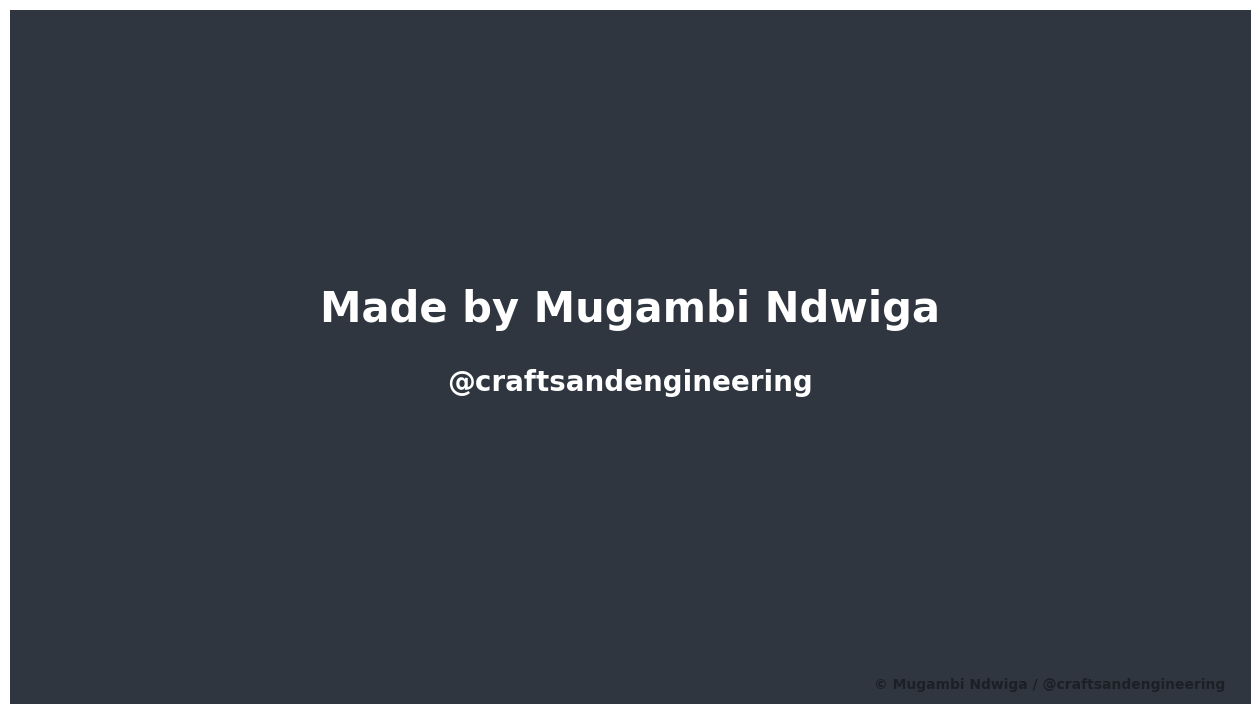

In [10]:
"""
Author: Mugambi Ndwiga
Instagram: @craftsandengineering
Concept: Bernoulli's Equation in a Venturi
GitHub: github.com/zombimann/Mathematical-video-animations-and-visualization
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap

# --- CONFIGURATION ---
cfg = {
    'width': 1280, 'height': 720,
    'fps': 30,
    'duration': 32,
    'palette': {
        'bg': '#ffffff',
        'text': '#2f3640',
        'p_high': '#ff7675',
        'p_low': '#74b9ff'
    },
    'scenes': {
        'hook': (0, 6),
        'variables': (6, 13),
        'simulation': (13, 23),
        'tradeoff': (23, 30),
        'closing': (30, 32)
    }
}

def venturi_width(x):
    return 0.4 - 0.25 * np.exp(-((x - 0.5) / 0.15)**2)

class VenturiSimulation:
    def __init__(self, n_particles=240): # X4 increase (60 -> 240)
        self.n = n_particles
        self.p_x = np.random.rand(n_particles)
        self.p_y_offset = np.random.uniform(-1, 1, n_particles)

    def update(self, dt=0.01):
        widths = venturi_width(self.p_x)
        vel = 0.15 / widths
        self.p_x += vel * dt
        mask = self.p_x > 1.05
        self.p_x[mask] = -0.05
        self.p_y_offset[mask] = np.random.uniform(-1, 1, np.sum(mask))
        p_y = self.p_y_offset * venturi_width(self.p_x) * 0.9
        return self.p_x, p_y, vel

def create_animation():
    plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif', 'font.weight': 'bold'})
    fig, ax = plt.subplots(figsize=(16, 9), facecolor=cfg['palette']['bg'])
    sim = VenturiSimulation()
    x_vals = np.linspace(0, 1, 200)
    w_vals = venturi_width(x_vals)

    # Pressure gradient colormap
    cmap_press = LinearSegmentedColormap.from_list('press', [cfg['palette']['p_low'], cfg['palette']['p_high']])
    # Velocity colormap for particles
    cmap_vel = plt.cm.Blues

    def animate(i):
        t = i / cfg['fps']
        ax.clear()
        ax.set_xlim(0, 1)
        ax.set_ylim(-0.5, 0.5)
        ax.axis('off')

        # Dynamic Pressure Gradient Background
        # Pressure is proportional to 1/v^2 which is proportional to area^2
        press_vals = (w_vals**2)
        press_norm = (press_vals - np.min(press_vals)) / (np.max(press_vals) - np.min(press_vals))
        for j in range(len(x_vals)-1):
            ax.fill_between(x_vals[j:j+2], -w_vals[j:j+2], w_vals[j:j+2],
                            color=cmap_press(press_norm[j]), alpha=0.3)

        ax.plot(x_vals, w_vals, color=cfg['palette']['text'], lw=3)
        ax.plot(x_vals, -w_vals, color=cfg['palette']['text'], lw=3)

        px, py, v = sim.update()
        # Color particles based on velocity
        v_norm = (v - np.min(v)) / (np.max(v) - np.min(v))
        ax.scatter(px, py, s=12, c=v_norm, cmap='cool', alpha=0.7)

        # Repositioned Text to avoid obstruction (Higher Y for labels, Lower Y for subtext)
        if t < cfg['scenes']['hook'][1]:
            ax.text(0.5, 0.45, "Bernoulli's Equation in a Venturi", ha='center', fontsize=32, color=cfg['palette']['text'])
            ax.text(0.5, -0.42, "Narrower path → faster flow → lower pressure", ha='center', fontsize=18, alpha=0.8)

        elif t < cfg['scenes']['variables'][1]:
            eq = r"$P + \frac{1}{2}\rho v^2 + \rho gy = \mathrm{constant}$"
            ax.text(0.5, 0.45, eq, ha='center', fontsize=36, color=cfg['palette']['text'])
            ax.text(0.1, -0.45, "P: Pressure", color='#2ecc71')
            ax.text(0.3, -0.45, "v: Velocity", color='#3498db')
            ax.text(0.5, -0.45, "ρ: Density", color='#9b59b6')

        elif t < cfg['scenes']['simulation'][1]:
            ax.annotate("High Pressure\nSlow Velocity", xy=(0.15, 0), xytext=(0.1, 0.35), arrowprops=dict(arrowstyle='->'))
            ax.annotate("Low Pressure\nHigh Velocity", xy=(0.5, 0), xytext=(0.45, 0.35), arrowprops=dict(arrowstyle='->', color='red'), color='red')

        elif t < cfg['scenes']['tradeoff'][1]:
            ax.text(0.5, 0.45, "Conservation of Energy", ha='center', fontsize=28)
            ax.text(0.5, -0.45, "Kinetic Energy increases as Pressure Energy decreases", ha='center', fontsize=20)

        elif t < cfg['scenes']['closing'][1]:
            ax.fill_between([0, 1], -0.5, 0.5, color=cfg['palette']['text'])
            ax.text(0.5, 0.05, "Made by Mugambi Ndwiga", color='white', ha='center', fontsize=30)
            ax.text(0.5, -0.05, "@craftsandengineering", color='white', ha='center', fontsize=20)

        ax.text(0.98, 0.02, "© Mugambi Ndwiga / @craftsandengineering", transform=ax.transAxes, ha='right', fontsize=10, alpha=0.4)

    ani = animation.FuncAnimation(fig, animate, frames=cfg['duration']*cfg['fps'], interval=1000/cfg['fps'])
    ani.save('bernoulli_venturi.mp4', writer='ffmpeg', fps=cfg['fps'], dpi=100, extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '25'])

create_animation()
print("Video generated: bernoulli_venturi.mp4")

In [11]:
from IPython.display import HTML
from base64 import b64encode
import os

def display_video(file_path):
    if not os.path.exists(file_path):
        print(f'File {file_path} not found.')
        return

    mp4 = open(file_path,'rb').read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
    return HTML(f"""
    <div style='text-align: center;'>
        <video width='720' height='405' controls autoplay loop>
            <source src='{data_url}' type='video/mp4'>
        </video>
        <br>
        <a href='{file_path}' download='bernoulli_venturi.mp4' style='font-family: sans-serif; text-decoration: none; background: #2ecc71; color: white; padding: 10px 20px; border-radius: 5px; display: inline-block; margin-top: 10px;'>Download Bernoulli Animation</a>
    </div>
    """)

display_video('bernoulli_venturi.mp4')